# Lab: k-Nearest Neighbors (KNN) Classification

*In this lab, we will build a k-Nearest Neighbors (KNN) model using scikit-learn to classify iris species, guided by the same structured [methodology](../../../05_methodology/) as in previous labs. This lab directly continues from the [baseline](./07_multi_class_classification_lab.ipynb), [decision tree](./10_decision_trees_lab.ipynb), and [SVM](./16_support_vector_machines_lab.ipynb) labs, leveraging the same processed dataset and domain understanding. The aim is to compare KNN’s performance and interpretability with our previous models.*

---

> ### 📝 1–5. Previous Stages Report (Summary)
> - **Business Context:** The overarching objective remains to automate the botanical classification of iris flowers (*setosa*, *versicolor*, *virginica*) for rapid, accurate, and consistent species identification in a research institute setting.
> - **Business Problem:** Human-based, manual iris identification is time-consuming and subject to error. Automated approaches expedite this process and improve reliability, especially for distinguishing scientifically important species like *Iris-virginica*.
> - **Analytic Approach:**  The species identification problem is framed as supervised multi-class classification. Previous labs established strong baselines with softmax regression, decision trees, and support vector machines (SVMs), using test-train splits and metrics such as accuracy, weighted/classwise precision, recall, F1-score, and confusion matrices.
> - **Data Requirements & Collection:** The classic scikit-learn iris dataset (four numeric features, three balanced species) was extracted, validated, cleaned, and saved in a processed format for reproducibility. This includes both the original anatomical features and two informative engineered features.
> - **Feature Engineering:**  During earlier labs, two new features were created:
>   - `petal_area` (`petal_length * petal_width`)  
>   - `sepal_ratio` (`sepal_length / sepal_width`)
>   The current lab will use this processed file for analysis and model building.
> - **Data Understanding:**  Exploratory data analysis confirmed:
>   - Petal-based features are highly predictive.
>   - The dataset is balanced and already pre-cleaned.
>   - Some natural outliers exist.
>   - Strong multicollinearity exists between petal length and petal width, motivating feature engineering.
>   - Prior models achieved high accuracy (typically 90%+), though certain species pairs (especially versicolor and virginica) remain trickier to separate.
> - **Transition to KNN Modeling:** This lab investigates k-Nearest Neighbors, a simple and interpretable non-parametric approach. KNN uses distance calculations between feature vectors for classification, so scaling and feature choices have a direct impact on model performance.

---

## Stage 6: Data Preparation

As in prior labs, we begin by importing the necessary libraries and configuring plotting and analysis preferences.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

Let's load our already processed dataset into a DataFrame:

In [3]:
iris_df = pd.read_parquet("../data/processed/iris_multi-class_processed_v1.parquet")
iris_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,target,class_name,petal_area,sepal_ratio
64,5.6,2.9,3.6,1.3,1,versicolor,4.68,1.931034
142,6.8,3.2,5.9,2.3,2,virginica,13.57,2.125000
128,6.4,2.8,5.6,2.1,2,virginica,11.76,2.285714
70,5.9,3.2,4.8,1.8,1,versicolor,8.64,1.843750
81,5.5,2.4,3.7,1.0,1,versicolor,3.70,2.291667


For simplicity and to highlight the impact of feature engineering, we'll use only the two engineered features as predictors.

Let's create the feature matrix and the target vector, split them, and do the scaling, which is essential for KNN.

In [4]:
X = iris_df[["petal_area", "sepal_ratio"]]
y = iris_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

> ### 📝 6. Data Preparation Report (Summary)
> - The cleaned, feature-engineered iris dataset was loaded from the standardized analytic file created in previous labs.
> - For this lab, **only the two engineered features** were selected as predictors:
>   - `petal_area` (captures overall petal size)
>   - `sepal_ratio` (captures the relative shape of the sepal)
>   This allows us to directly assess the predictive power of domain-informed feature engineering.
> - The target variable remains the original multi-class species label (`target`).
> - The dataset was split into training and test sets (80/20) using stratified sampling to preserve the natural balance of the three iris species. This ensures fair and robust evaluation.
> - **Standardization using `StandardScaler`** was applied to the predictor variables, as KNN is especially sensitive to the scale of features since it relies on Euclidean distance for classification.
> - The resulting scaled train and test datasets are now ready for k-Nearest Neighbors modeling and evaluation.

---

## Stage 7: Modeling

In [5]:
# Create and fit the model
neigh = KNeighborsClassifier(n_neighbors=3).fit(X_train_scaled, y_train)


---

> ### 📝 7. Modeling Report (Summary)
> - A k-Nearest Neighbors (KNN) classifier was selected for this stage to provide a simple, interpretable, and non-parametric approach to multi-class classification.
> - The KNN model was configured with `n_neighbors=3`, considering the balanced class distribution and manageable dataset size. This setting enables each prediction to be based on the three closest examples in the feature space.
> - The model was trained using only the engineered features (`petal_area` and `sepal_ratio`), both of which were scaled for fair distance calculation, following the best practices for KNN.
> - No cross-validation or hyperparameter tuning was performed at this stage—experimentation with model parameters and advanced validation strategies will be introduced in a later module.
> - The trained KNN model is now ready for evaluation on the standardized, hold-out test set using the established multi-class evaluation metrics.

---

## Stage 8: Evaluation

In [6]:
# Predict on the test set
y_pred = neigh.predict(X_test_scaled)

In [7]:
# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Evaluation Metrics on Test Set:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

Evaluation Metrics on Test Set:
  Accuracy : 0.9667
  Precision: 0.9697
  Recall   : 0.9667
  F1-Score : 0.9666


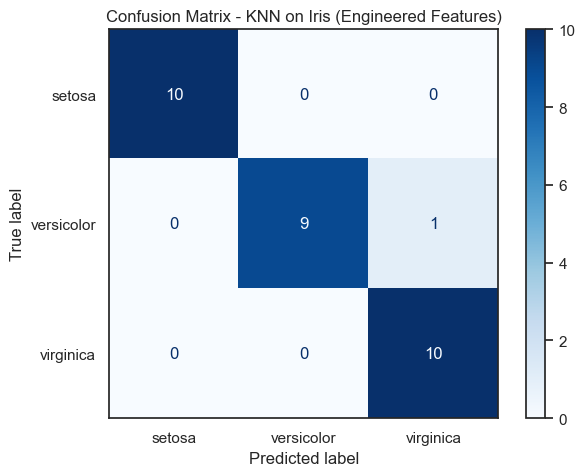

In [8]:
# Display the confusion matrix using species names
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['setosa', 'versicolor', 'virginica'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN on Iris (Engineered Features)")
plt.show()


---

> ### 📝 8. Evaluation Report (Summary)
> - The trained k-Nearest Neighbors (KNN) model (with `n_neighbors=3`) was evaluated on the hold-out test set using standard multi-class classification metrics.
> - **Evaluation Results:** Accuracy: 96.67%, Precision: 96.97%, Recall: 96.67%, F1-Score: 96.66%
> - **Interpretation:**
>     - The KNN model achieved near-perfect classification on the test set, with only a single misclassification (a versicolor flower predicted as virginica).
>     - All setosa and virginica samples were classified correctly.
> - No cross-validation or hyperparameter search was performed in this lab, consistent with current course objectives. These advanced validation and tuning strategies will be introduced and applied in future modules.
> - The KNN approach demonstrates excellent performance using just two engineered features, establishing it as a strong, interpretable baseline for multi-class classification on the iris dataset.

---

**Next:** [Naive Bayes Theory](./20_naive_bayes_theory.md)